In [4]:
# Run this in your Jupyter cell
!pip install pandas sqlalchemy pymysql

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import sqlite3
import os

# 1. Setup Connection
conn = sqlite3.connect('maven_market.db')

# 2. Define your folder path (using the 'r' for the Windows path as we discussed)
folder_path = r'C:\Users\shiek\OneDrive\Documents\Projects - DA\8 - SQL'

# 3. List of files (Using underscores instead of hyphens for the returns table)
files = {
    'MavenMarket_Calendar.csv': 'mavenmarket_calendar',
    'MavenMarket_Customers.csv': 'mavenmarket_customers',
    'MavenMarket_Products.csv': 'mavenmarket_products',
    'MavenMarket_Regions.csv': 'mavenmarket_regions',
    'MavenMarket_Returns_1997-1998.csv': 'mavenmarket_returns_1997_1998',
    'MavenMarket_Stores.csv': 'mavenmarket_stores',
    'MavenMarket_Transactions_1997.csv': 'mavenmarket_transactions_1997',
    'MavenMarket_Transactions_1998.csv': 'mavenmarket_transactions_1998'
}

# 4. Upload Loop
for csv_file, table_name in files.items():
    full_path = os.path.join(folder_path, csv_file)
    if os.path.exists(full_path):
        print(f"Uploading {csv_file} to table {table_name}...")
        df = pd.read_csv(full_path)
        df.to_sql(table_name, conn, if_exists='replace', index=False)
    else:
        print(f"FILE NOT FOUND: {full_path}")

# 5. Verify
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("\nTables now in database:")
print(tables)

conn.close()

Uploading MavenMarket_Calendar.csv to table mavenmarket_calendar...
Uploading MavenMarket_Customers.csv to table mavenmarket_customers...
Uploading MavenMarket_Products.csv to table mavenmarket_products...
Uploading MavenMarket_Regions.csv to table mavenmarket_regions...
Uploading MavenMarket_Returns_1997-1998.csv to table mavenmarket_returns_1997_1998...
Uploading MavenMarket_Stores.csv to table mavenmarket_stores...
Uploading MavenMarket_Transactions_1997.csv to table mavenmarket_transactions_1997...
Uploading MavenMarket_Transactions_1998.csv to table mavenmarket_transactions_1998...

Tables now in database:
                            name
0   mavenmarket_transactions_all
1           mavenmarket_calendar
2          mavenmarket_customers
3           mavenmarket_products
4            mavenmarket_regions
5  mavenmarket_returns_1997_1998
6             mavenmarket_stores
7  mavenmarket_transactions_1997
8  mavenmarket_transactions_1998


In [6]:
import pandas as pd
import sqlite3


conn = sqlite3.connect('maven_market.db')

date_tasks = {
    'mavenmarket_calendar': ['date'],
    'mavenmarket_customers': ['birthdate', 'acct_open_date'],
    'mavenmarket_stores': ['first_opened_date', 'last_remodel_date'],
    'mavenmarket_returns_1997_1998': ['return_date'], 
    'mavenmarket_transactions_1997': ['transaction_date', 'stock_date'],
    'mavenmarket_transactions_1998': ['transaction_date', 'stock_date']
}

for table, columns in date_tasks.items():
    print(f"Cleaning dates in {table}...")
    df = pd.read_sql(f'SELECT * FROM "{table}"', conn)
    
    for col in columns:
        df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')
    
    df.to_sql(table, conn, if_exists='replace', index=False)
print(f"\nVerification of {table} data types:")
print(df.dtypes)

conn.close()

Cleaning dates in mavenmarket_calendar...
Cleaning dates in mavenmarket_customers...
Cleaning dates in mavenmarket_stores...
Cleaning dates in mavenmarket_returns_1997_1998...
Cleaning dates in mavenmarket_transactions_1997...
Cleaning dates in mavenmarket_transactions_1998...

Verification of mavenmarket_transactions_1998 data types:
transaction_date    datetime64[ns]
stock_date          datetime64[ns]
product_id                   int64
customer_id                  int64
store_id                     int64
quantity                     int64
dtype: object


In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('maven_market.db')
df_products = pd.read_sql('SELECT * FROM mavenmarket_products', conn)

cols_to_fix = ['recyclable', 'low_fat']
df_products[cols_to_fix] = df_products[cols_to_fix].fillna(0)

df_products.to_sql('mavenmarket_products', conn, if_exists='replace', index=False)

null_counts = df_products[cols_to_fix].isnull().sum()
print("Null counts after cleaning:")
print(null_counts)

conn.close()

Null counts after cleaning:
recyclable    0
low_fat       0
dtype: int64


In [8]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('maven_market.db')
df_customers = pd.read_sql('SELECT * FROM mavenmarket_customers', conn)


df_customers['full_name'] = df_customers['first_name'] + ' ' + df_customers['last_name']
cols_to_strip = ['occupation', 'member_card']
for col in cols_to_strip:
    df_customers[col] = df_customers[col].str.strip()

df_customers = df_customers.drop(columns=['first_name', 'last_name'])
df_customers.to_sql('mavenmarket_customers', conn, if_exists='replace', index=False)

conn.close()

In [9]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('maven_market.db')
df_customers = pd.read_sql('SELECT * FROM mavenmarket_customers', conn)

df_customers['homeowner'] = df_customers['homeowner'].replace({'Y': 1, 'N': 0})
df_customers.to_sql('mavenmarket_customers', conn, if_exists='replace', index=False)

conn.close()

C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\804556588.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_customers['homeowner'] = df_customers['homeowner'].replace({'Y': 1, 'N': 0})


In [10]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('maven_market.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]

print("--- DATABASE SCHEMA VALIDATION ---")
for table in tables:
    df = pd.read_sql(f'SELECT * FROM "{table}"', conn)
    print(f"\nTable: {table}")
    print(df.dtypes)

conn.close()

--- DATABASE SCHEMA VALIDATION ---

Table: mavenmarket_transactions_all
transaction_date    object
stock_date          object
product_id           int64
customer_id          int64
store_id             int64
quantity             int64
dtype: object

Table: mavenmarket_regions
region_id          int64
sales_district    object
sales_region      object
dtype: object

Table: mavenmarket_calendar
date    object
dtype: object

Table: mavenmarket_stores
store_id                 int64
region_id                int64
store_type              object
store_name              object
store_street_address    object
store_city              object
store_state             object
store_country           object
store_phone             object
first_opened_date       object
last_remodel_date       object
total_sqft               int64
grocery_sqft             int64
dtype: object

Table: mavenmarket_returns_1997_1998
return_date    object
product_id      int64
store_id        int64
quantity        int64
dtype: 

In [11]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('maven_market.db')
df1 = pd.read_sql('SELECT * FROM mavenmarket_transactions_1997', conn)
df2 = pd.read_sql('SELECT * FROM mavenmarket_transactions_1998', conn)

df_transactions = pd.concat([df1, df2], ignore_index=True)
df_transactions.to_sql('mavenmarket_transactions_all', conn, if_exists='replace', index=False)

269720

In [12]:
df_customers = pd.read_sql('SELECT * FROM mavenmarket_customers', conn)

df_customers['member_card'] = df_customers['member_card'].str.strip().str.title()
df_customers['occupation'] = df_customers['occupation'].str.strip().str.title()

df_customers.to_sql('mavenmarket_customers', conn, if_exists='replace', index=False)

10281

In [13]:
df_cal = pd.read_sql('SELECT * FROM mavenmarket_calendar', conn, parse_dates=['date'])

df_cal['day_name'] = df_cal['date'].dt.day_name()
df_cal['month_name'] = df_cal['date'].dt.month_name()
df_cal['year'] = df_cal['date'].dt.year

df_cal['is_weekend'] = df_cal['date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
df_cal.to_sql('mavenmarket_calendar', conn, if_exists='replace', index=False)

730

In [14]:
df_customers['birthdate'] = pd.to_datetime(df_customers['birthdate'])
df_customers['birth_year'] = df_customers['birthdate'].dt.year

df_customers['has_children'] = df_customers['total_children'].apply(lambda x: 1 if x > 0 else 0)
df_customers.to_sql('mavenmarket_customers', conn, if_exists='replace', index=False)

10281

In [15]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('maven_market.db')
df_trans = pd.read_sql('SELECT * FROM mavenmarket_transactions_all', conn)

df_prod = pd.read_sql('SELECT * FROM mavenmarket_products', conn)
df_cust = pd.read_sql('SELECT * FROM mavenmarket_customers', conn)
df_stores = pd.read_sql('SELECT * FROM mavenmarket_stores', conn)

df_final = df_trans.merge(df_prod, on='product_id', how='left') \
                  .merge(df_cust, on='customer_id', how='left') \
                  .merge(df_stores, on='store_id', how='left')

print(df_final.head())

      transaction_date           stock_date  product_id  customer_id  \
0  1997-01-01 00:00:00  1996-12-31 00:00:00         869         3449   
1  1997-01-01 00:00:00  1996-12-31 00:00:00        1472         3449   
2  1997-01-01 00:00:00  1996-12-28 00:00:00          76         3449   
3  1997-01-01 00:00:00  1996-12-26 00:00:00         320         3449   
4  1997-01-01 00:00:00  1996-12-25 00:00:00           4         3449   

   store_id  quantity product_brand                product_name  product_sku  \
0         6         5     Nationeel  Nationeel Grape Fruit Roll  52382137179   
1         6         3     Fort West     Fort West Fudge Cookies  37276054024   
2         6         4     Red Spade    Red Spade Sliced Chicken  62054644227   
3         6         3     Excellent   Excellent Cranberry Juice  36570182442   
4         6         4    Washington       Washington Cream Soda  64412155747   

   product_retail_price  ...  store_name       store_street_address  \
0              

In [16]:
import pandas as pd
import sqlite3
import numpy as np

conn = sqlite3.connect('maven_market.db')
df_trans = pd.read_sql('SELECT * FROM mavenmarket_transactions_all', conn, parse_dates=['transaction_date', 'stock_date'])
df_prod = pd.read_sql('SELECT * FROM mavenmarket_products', conn)
df_cust = pd.read_sql('SELECT * FROM mavenmarket_customers', conn)
df_stores = pd.read_sql('SELECT * FROM mavenmarket_stores', conn)
df_regions = pd.read_sql('SELECT * FROM mavenmarket_regions', conn)
df_returns = pd.read_sql('SELECT * FROM mavenmarket_returns_1997_1998', conn)

df_master = df_trans.merge(df_prod, on='product_id', how='left') \
                   .merge(df_cust, on='customer_id', how='left') \
                   .merge(df_stores, on='store_id', how='left') \
                   .merge(df_regions, on='region_id', how='left')

df_master['revenue'] = df_master['quantity'] * df_master['product_retail_price']
df_master['cost'] = df_master['quantity'] * df_master['product_cost']
df_master['profit'] = df_master['revenue'] - df_master['cost']
df_master['processing_time'] = (df_master['transaction_date'] - df_master['stock_date']).dt.days

print("Master Analytical Frame Created!")

Master Analytical Frame Created!


KPI's

In [17]:
# Calculations
total_transactions = len(df_master)
total_qty = df_master['quantity'].sum()
total_rev = df_master['revenue'].sum()
total_cost = df_master['cost'].sum()
total_profit = total_rev - total_cost
total_returns = df_returns['quantity'].sum()
ret_rate = (total_returns / total_transactions) * 100
prof_margin = (total_profit / total_rev) * 100

print(f"--- GLOBAL KPIs ---")
print(f"Total Revenue: ${total_rev:,.2f}")
print(f"Total Profit: ${total_profit:,.2f} (Margin: {prof_margin:.2f}%)")
print(f"Return Rate: {ret_rate:.2f}%")

--- GLOBAL KPIs ---
Total Revenue: $1,764,546.44
Total Profit: $1,052,818.78 (Margin: 59.67%)
Return Rate: 3.07%


In [18]:
top_products = df_master.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)
reg_revenue = df_master.groupby('sales_region')['revenue'].sum().sort_values(ascending=False)

store_perf = df_master.groupby('store_type').agg({'revenue': 'sum', 'profit': 'mean'})

print("\n--- TOP 10 PRODUCTS BY PROFIT ---")
print(top_products)


--- TOP 10 PRODUCTS BY PROFIT ---
product_name
Hermanos Green Pepper                 1670.55
Imagine Popsicles                     1513.89
Hilltop Mint Mouthwash                1493.96
Super Extra Chunky Peanut Butter      1484.73
Nationeel Potato Chips                1479.50
Fabulous Strawberry Drink             1474.90
Booker Strawberry Yogurt              1452.56
BBB Best Apple Preserves              1439.90
Hermanos New Potatos                  1431.08
High Quality Scented Toilet Tissue    1413.28
Name: profit, dtype: float64


In [19]:
occ_revenue = df_master.groupby('occupation')['revenue'].sum().sort_values(ascending=False)
card_impact = df_master.groupby('member_card')['revenue'].mean().sort_values(ascending=False)
customer_spend = df_master.groupby('full_name')['revenue'].sum().sort_values(ascending=False)
top_1_percent = customer_spend.head(int(len(customer_spend)*0.01))

print(f"\nTop 1% of Customers contribute: ${top_1_percent.sum():,.2f} in revenue.")


Top 1% of Customers contribute: $127,740.27 in revenue.


In [20]:
df_master.set_index('transaction_date', inplace=True)
monthly_rev = df_master['revenue'].resample('ME').sum()

rev_1997 = df_master[df_master.index.year == 1997]['revenue'].sum()
rev_1998 = df_master[df_master.index.year == 1998]['revenue'].sum()
yoy_growth = ((rev_1998 - rev_1997) / rev_1997) * 100

print(f"\nYoY Revenue Growth: {yoy_growth:.2f}%")


YoY Revenue Growth: 112.18%


In [21]:
correlation = df_master['quantity'].corr(df_master['revenue'])
avg_lead_time = df_master['processing_time'].mean()

print(f"\nCorrelation (Qty vs Revenue): {correlation:.2f}")
print(f"Avg Stock-to-Sale Duration: {avg_lead_time:.1f} days")


Correlation (Qty vs Revenue): 0.51
Avg Stock-to-Sale Duration: 3.9 days


In [22]:
latest_date = df_master.index.max()
last_month_start = latest_date - pd.DateOffset(months=1)
last_month_profit = df_master[df_master.index >= last_month_start]['profit'].sum()

edu_segment = df_master.groupby('education')['revenue'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

df_returns_detailed = df_returns.merge(df_prod, on='product_id', how='left')\
                                .merge(df_stores, on='store_id', how='left')

returns_by_brand = df_returns_detailed.groupby('product_brand')['quantity'].sum().sort_values(ascending=False)
returns_by_city = df_returns_detailed.groupby('store_city')['quantity'].sum().sort_values(ascending=False)

lost_revenue = (df_returns_detailed['quantity'] * df_returns_detailed['product_retail_price']).sum()
return_impact_pct = (lost_revenue / total_rev) * 100

cust_97 = set(df_master[df_master.index.year == 1997]['customer_id'])
cust_98 = set(df_master[df_master.index.year == 1998]['customer_id'])
retained_customers = cust_97.intersection(cust_98)
churned_customers = cust_97 - cust_98
retention_rate = (len(retained_customers) / len(cust_97)) * 100

basket = df_master.reset_index()
basket = basket.groupby(['customer_id', 'transaction_date'])['product_brand'].apply(list)
basket = basket[basket.apply(len) > 1]

has_reasons = 'return_description' in df_returns.columns or 'reason' in df_returns.columns

print(f"Last Month Profit: ${last_month_profit:,.2f}")
print(f"Customer Retention Rate: {retention_rate:.2f}%")
print(f"Revenue Lost to Returns: ${lost_revenue:,.2f} ({return_impact_pct:.2f}% of total)")
if not has_reasons:
    print("Note: 'Return Reasons' column not found in raw data; results based on volume only.")

Last Month Profit: $73,737.97
Customer Retention Rate: 85.99%
Revenue Lost to Returns: $17,432.40 (0.99% of total)
Note: 'Return Reasons' column not found in raw data; results based on volume only.


C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\4152206557.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=['1997', '1998'], y=[rev_1997, rev_1998], palette='viridis')
C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\4152206557.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x='Metric', y='Value', data=financials, palette='magma')


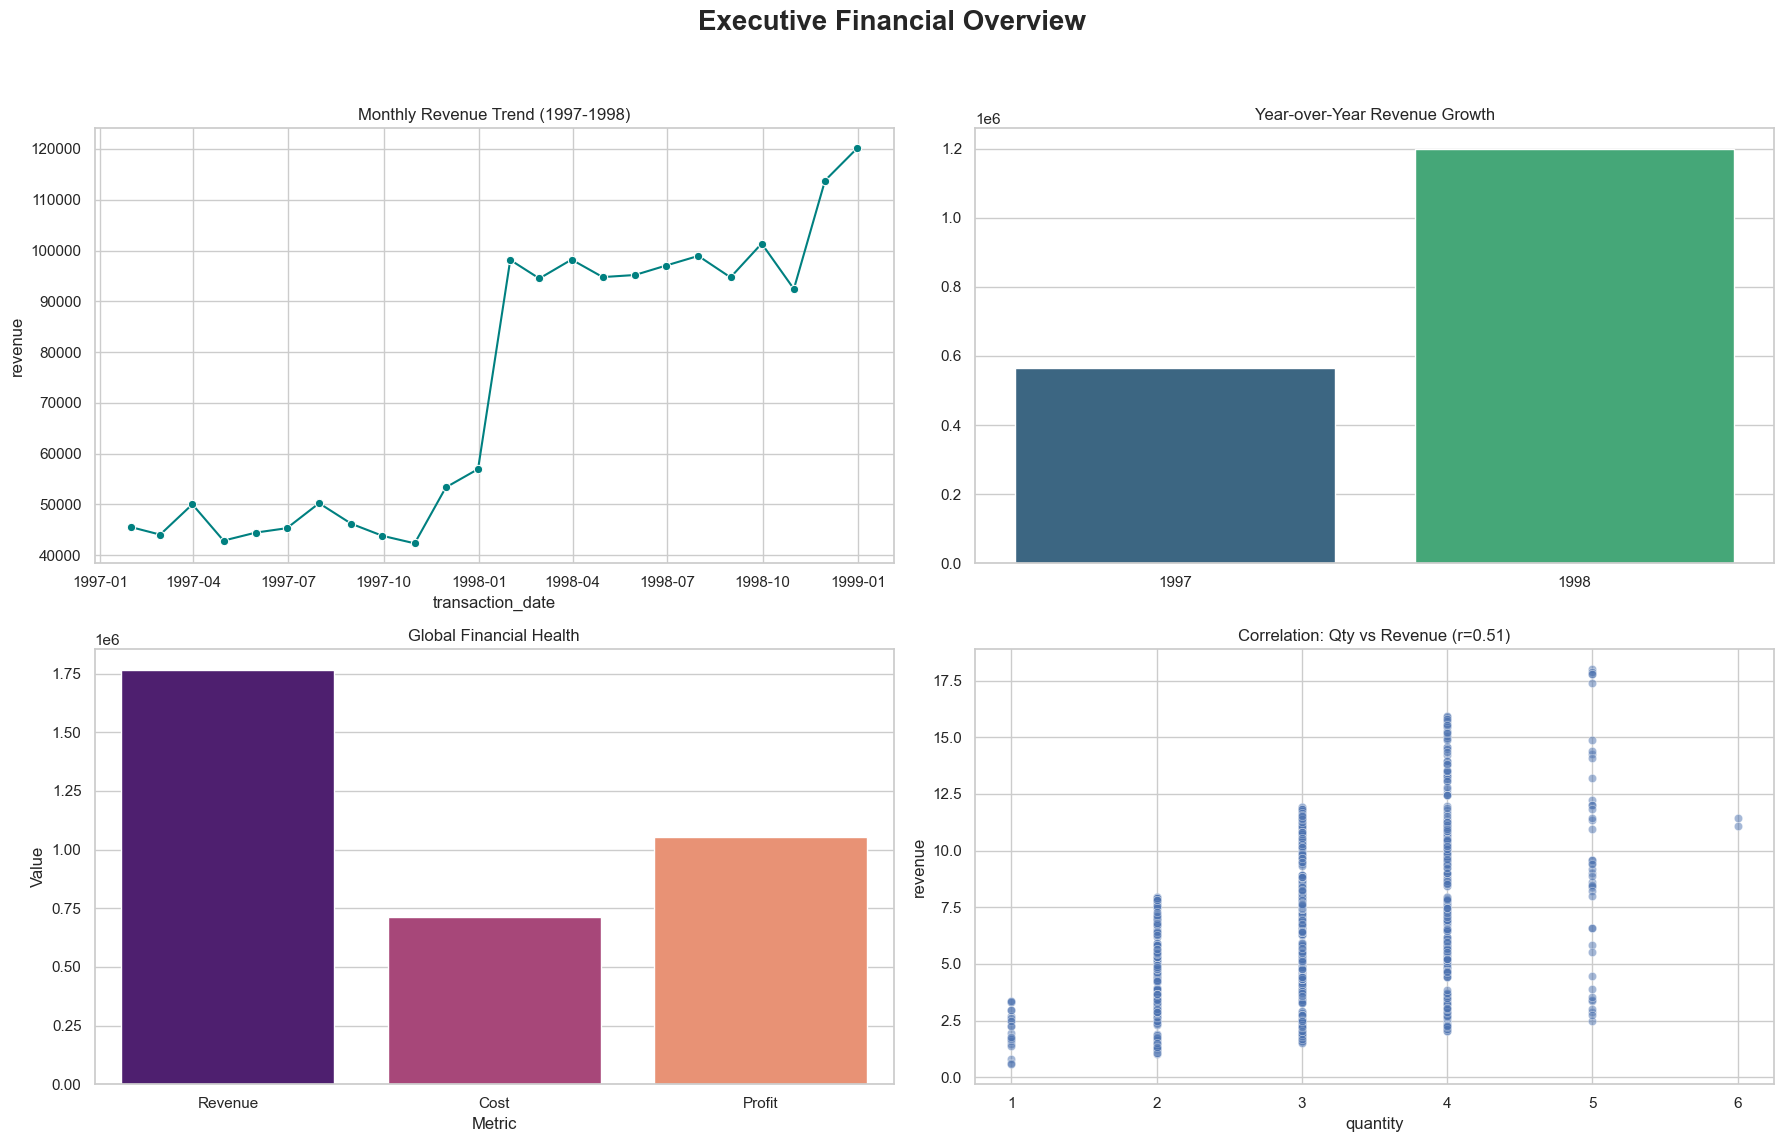

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Executive Financial Overview', fontsize=20, fontweight='bold')

sns.lineplot(ax=axes[0, 0], data=monthly_rev, marker='o', color='teal')
axes[0, 0].set_title('Monthly Revenue Trend (1997-1998)')

sns.barplot(ax=axes[0, 1], x=['1997', '1998'], y=[rev_1997, rev_1998], palette='viridis')
axes[0, 1].set_title('Year-over-Year Revenue Growth')

financials = pd.DataFrame({'Metric': ['Revenue', 'Cost', 'Profit'], 
                           'Value': [total_rev, total_cost, total_profit]})
sns.barplot(ax=axes[1, 0], x='Metric', y='Value', data=financials, palette='magma')
axes[1, 0].set_title('Global Financial Health')

sns.scatterplot(ax=axes[1, 1], x='quantity', y='revenue', data=df_master.sample(1000), alpha=0.5)
axes[1, 1].set_title(f'Correlation: Qty vs Revenue (r={correlation:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\2165085044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=top_products.values, y=top_products.index, palette='Blues_r')
C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\2165085044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=reg_revenue.values, y=reg_revenue.index, palette='rocket')


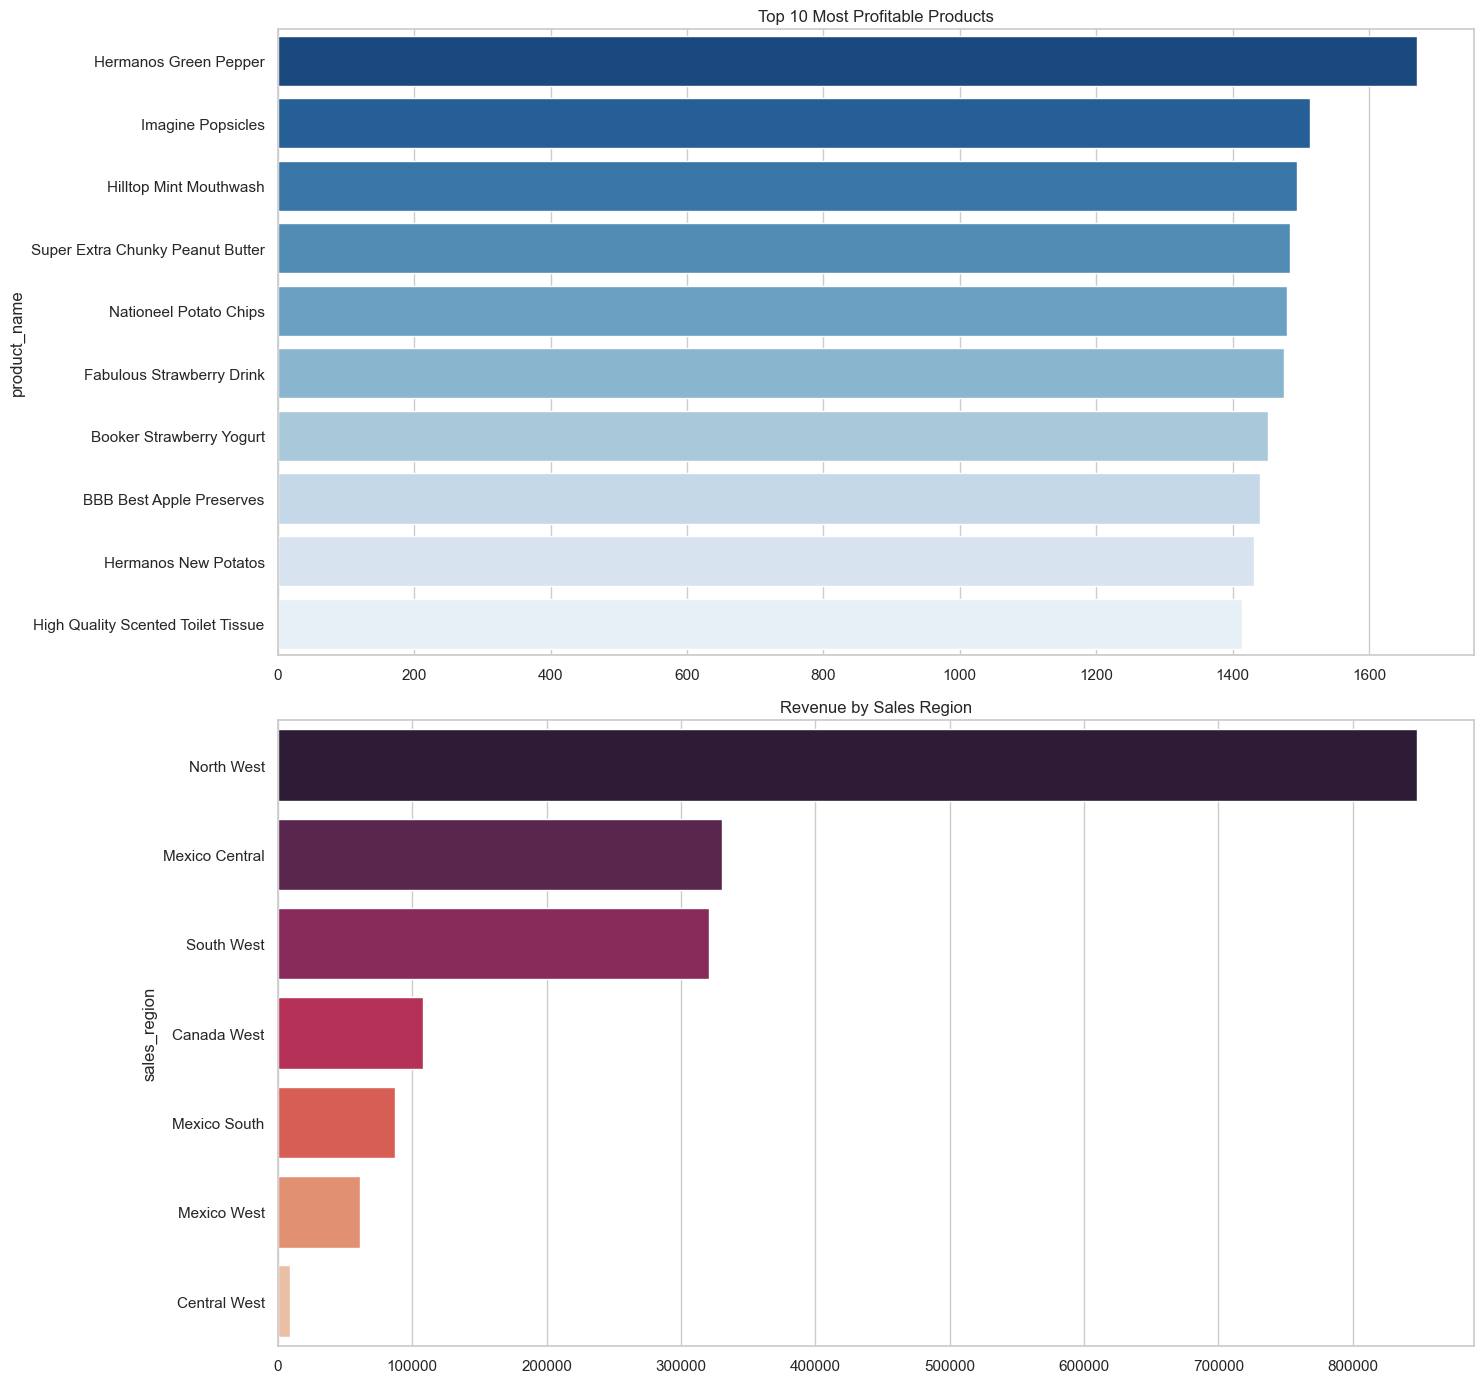

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(15, 14))

sns.barplot(ax=axes[0], x=top_products.values, y=top_products.index, palette='Blues_r')
axes[0].set_title('Top 10 Most Profitable Products')

sns.barplot(ax=axes[1], x=reg_revenue.values, y=reg_revenue.index, palette='rocket')
axes[1].set_title('Revenue by Sales Region')

plt.tight_layout()
plt.show()

C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\3460084553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x=occ_revenue.values, y=occ_revenue.index, palette='Set2')
C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\3460084553.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x='member_card', y='revenue', data=df_master, palette='Pastel1')
C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\3460084553.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x=edu_segment.index, y=edu_segment['su

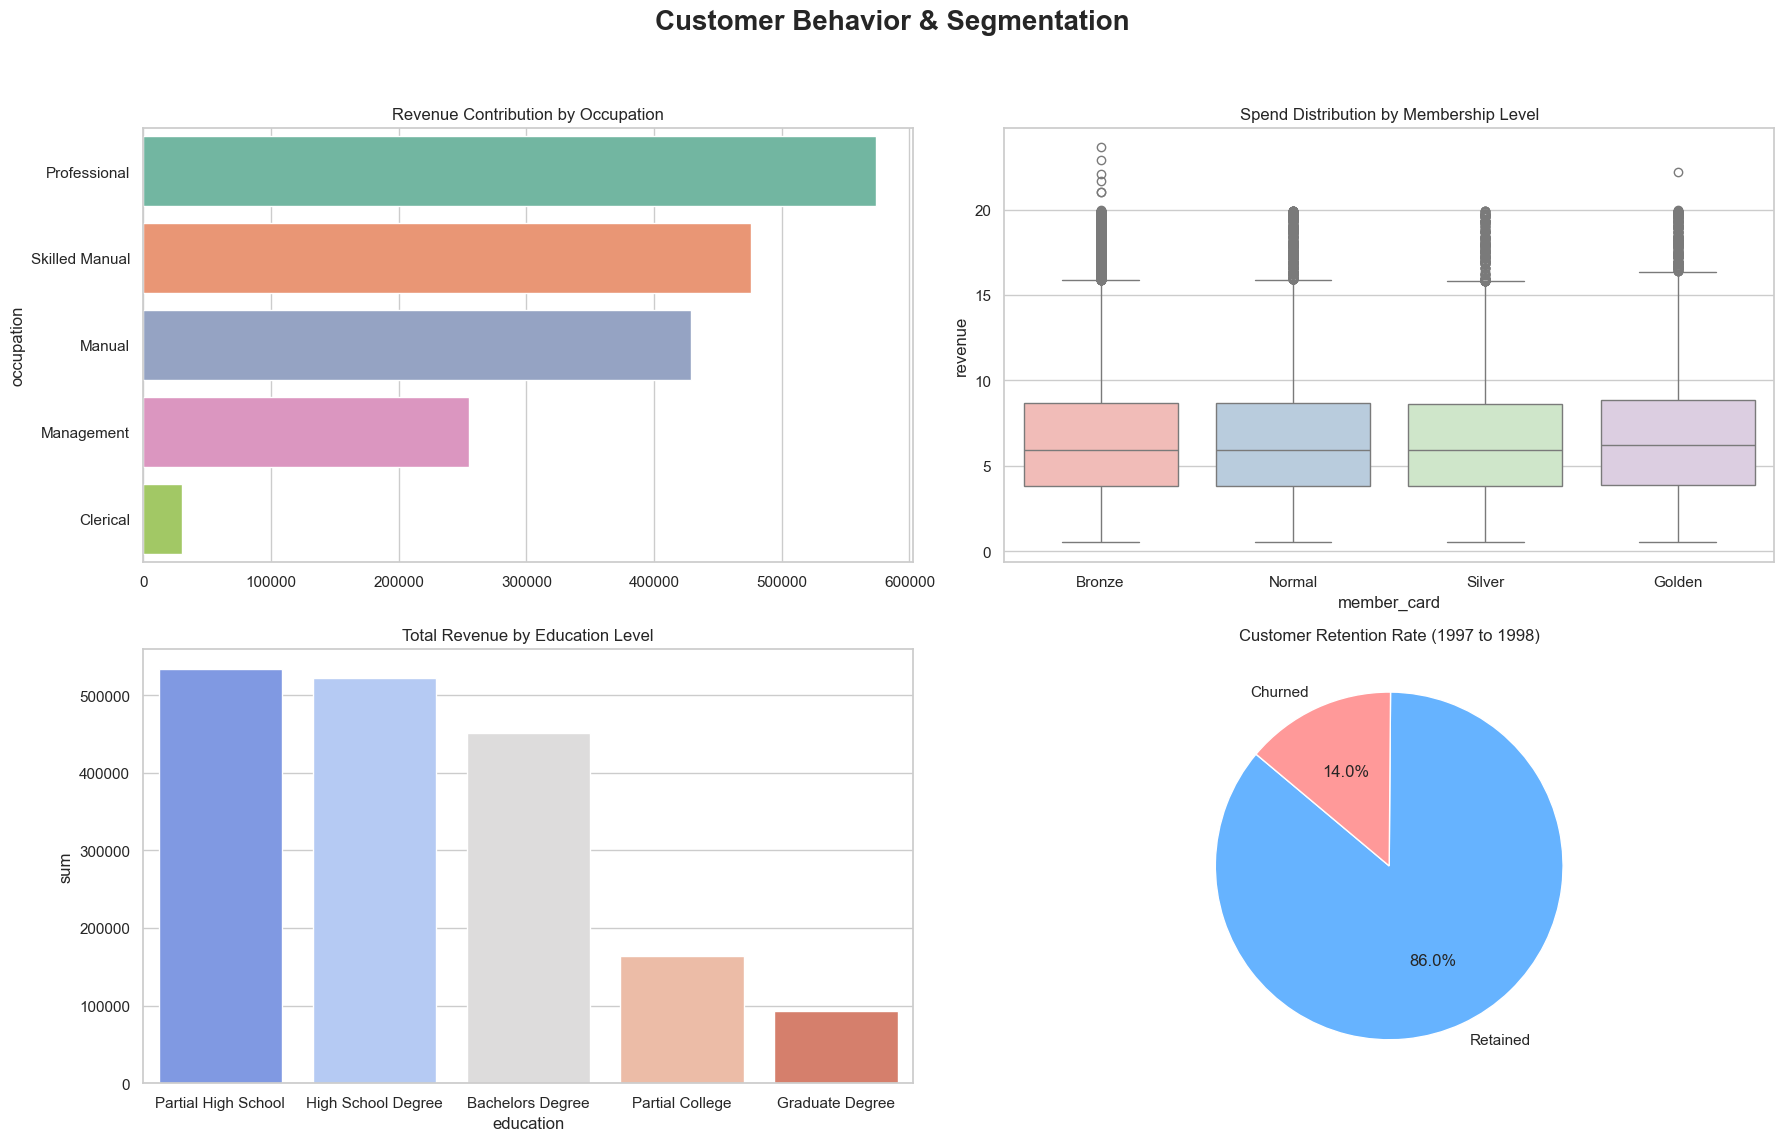

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Customer Behavior & Segmentation', fontsize=20, fontweight='bold')

sns.barplot(ax=axes[0, 0], x=occ_revenue.values, y=occ_revenue.index, palette='Set2')
axes[0, 0].set_title('Revenue Contribution by Occupation')

sns.boxplot(ax=axes[0, 1], x='member_card', y='revenue', data=df_master, palette='Pastel1')
axes[0, 1].set_title('Spend Distribution by Membership Level')

sns.barplot(ax=axes[1, 0], x=edu_segment.index, y=edu_segment['sum'], palette='coolwarm')
axes[1, 0].set_title('Total Revenue by Education Level')

labels = ['Retained', 'Churned']
sizes = [len(retained_customers), len(churned_customers)]
axes[1, 1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
axes[1, 1].set_title('Customer Retention Rate (1997 to 1998)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\1593000536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=returns_by_city.head(10).values, y=returns_by_city.head(10).index, palette='Reds_r')


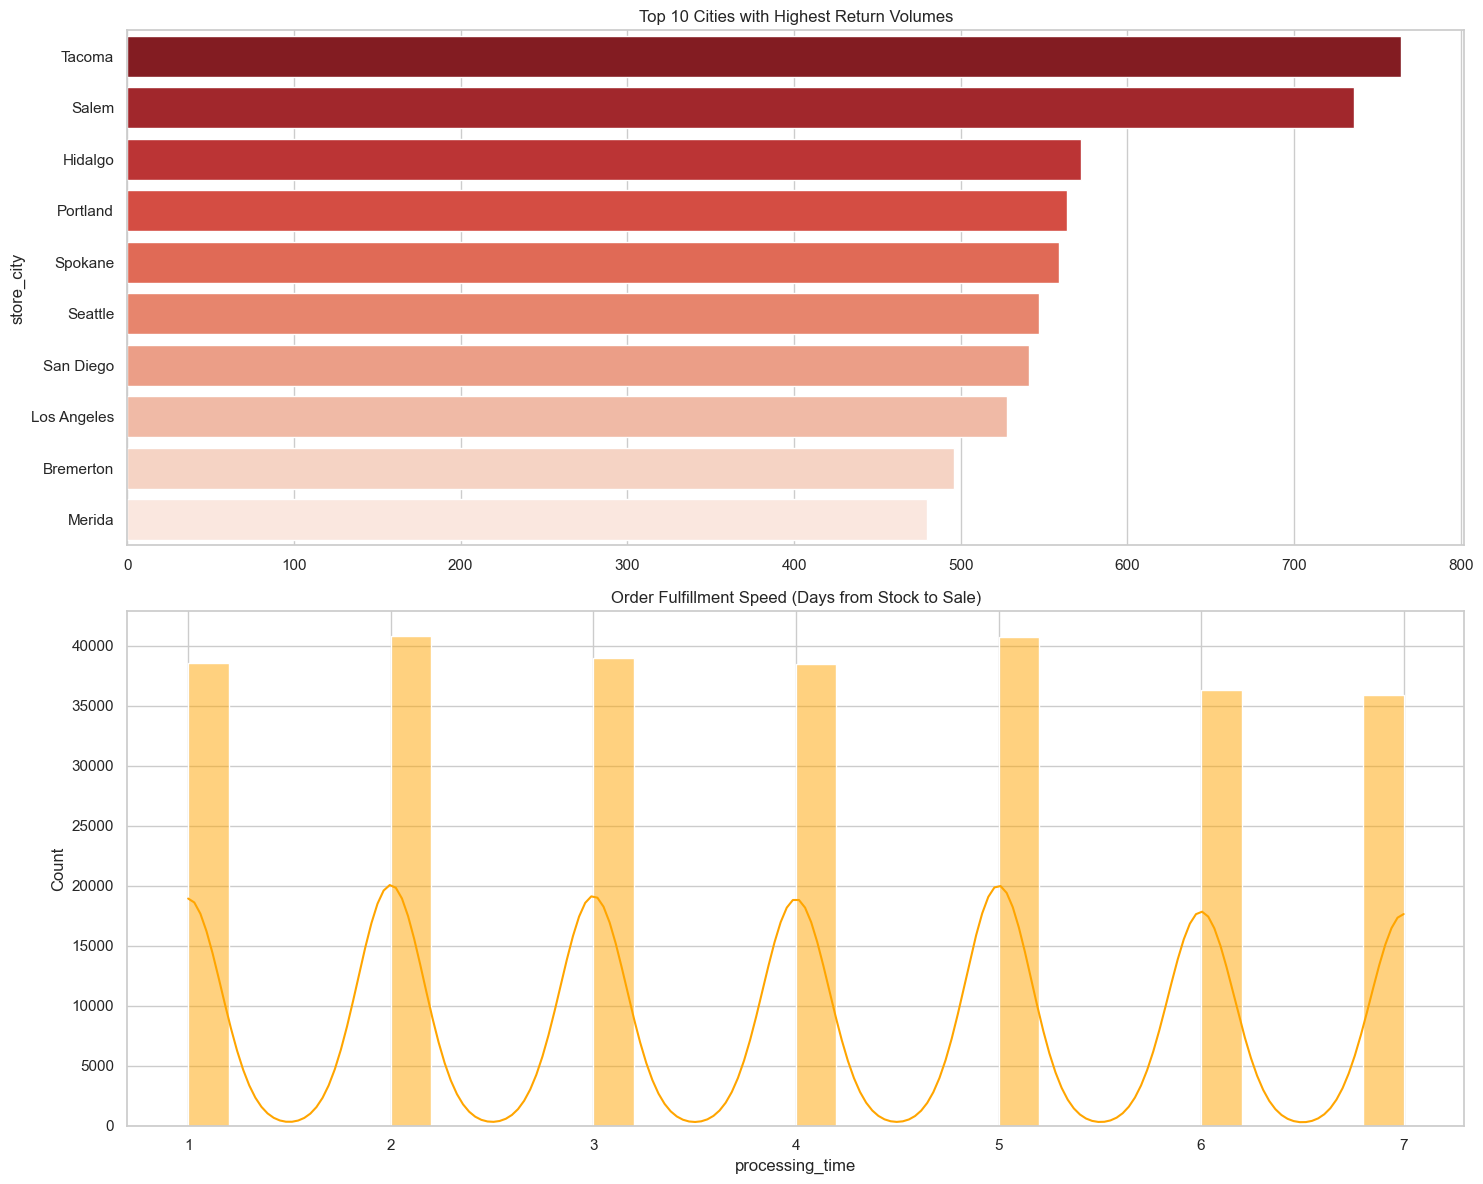

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.barplot(ax=axes[0], x=returns_by_city.head(10).values, y=returns_by_city.head(10).index, palette='Reds_r')
axes[0].set_title('Top 10 Cities with Highest Return Volumes')

sns.histplot(ax=axes[1], x=df_master['processing_time'], bins=30, kde=True, color='orange')
axes[1].set_title('Order Fulfillment Speed (Days from Stock to Sale)')

plt.tight_layout()
plt.show()

In [28]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd

# --- GLOBAL STYLING ---
# Professional "Maven Midnight" Palette
MAVEN_NAVY = "#1B4F72"
MAVEN_TEAL = "#008080"
MAVEN_GOLD = "#D4AC0D"
MAVEN_GRAY = "#2C3E50"
MAVEN_RED  = "#C0392B"
MAVEN_BG   = "#F4F7F6" # Subtle light-gray background

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'text.color': MAVEN_GRAY,
    'axes.labelcolor': MAVEN_GRAY,
    'xtick.color': MAVEN_GRAY,
    'ytick.color': MAVEN_GRAY,
    'axes.titleweight': 'bold',
    'axes.titlesize': 18,
    'axes.titlepad': 20
})

pdf_filename = "Maven_Market_Professional_Report.pdf"

with PdfPages(pdf_filename) as pdf:
    
    # --- PAGE 1: COVER PAGE (High Contrast) ---
    plt.figure(figsize=(11, 8.5), facecolor=MAVEN_NAVY)
    plt.axis('off')
    plt.text(0.5, 0.65, "MAVEN MARKET", ha='center', fontsize=50, fontweight='bold', color='white')
    plt.text(0.5, 0.55, "BUSINESS PERFORMANCE AUDIT", ha='center', fontsize=24, color='#AED6F1')
    plt.text(0.5, 0.45, "Fiscal Period: 1997 - 1998", ha='center', fontsize=18, color='white')
    plt.axhline(y=0.4, xmin=0.3, xmax=0.7, color=MAVEN_GOLD, linewidth=3)
    plt.text(0.5, 0.15, "Automated via PySQL Pipeline", ha='center', fontsize=10, color='white', style='italic')
    pdf.savefig()
    plt.close()

    # --- PAGE 2: ARCHITECTURE (Clean & Structured) ---
    plt.figure(figsize=(11, 8.5))
    plt.axis('off')
    plt.gca().add_patch(plt.Rectangle((0, 0.85), 1, 0.15, color=MAVEN_NAVY, transform=plt.gca().transAxes))
    plt.text(0.05, 0.92, "Methodology & Data Pipeline", color='white', fontsize=22, fontweight='bold', transform=plt.gca().transAxes)
    
    methods = [
        "DATABASE: SQLite Star Schema for relational efficiency.",
        "INGESTION: Scalable ETL scripts using Pandas & SQLAlchemy.",
        "MODELING: Normalized Dimensions connected to Transactional Facts.",
        "ANALYSIS: Vectorized calculations for real-time KPI generation."
    ]
    for i, m in enumerate(methods):
        plt.text(0.05, 0.7 - (i*0.1), f"• {m}", fontsize=15, linespacing=1.8)
    pdf.savefig()
    plt.close()

    # --- PAGE 3: FINANCIALS (Executive Bar Chart) ---
    fig, ax = plt.subplots(figsize=(11, 8.5))
    financials = pd.DataFrame({'Metric': ['Revenue', 'Cost', 'Profit'], 
                               'Value': [total_rev, total_cost, total_profit]})
    sns.barplot(x='Metric', y='Value', data=financials, palette=[MAVEN_NAVY, MAVEN_GRAY, MAVEN_TEAL], ax=ax)
    ax.set_title(f'Global Performance Overview (Margin: {prof_margin:.1f}%)')
    sns.despine()
    pdf.savefig()
    plt.close()

    # --- PAGE 4: TIME TRENDS (Modern Line Plot) ---
    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
    sns.lineplot(ax=axes[0], data=monthly_rev, marker='o', color=MAVEN_TEAL, linewidth=3, markersize=8)
    axes[0].set_title('Strategic Revenue Trajectory', color=MAVEN_NAVY)
    
    sns.barplot(ax=axes[1], x=['1997', '1998'], y=[rev_1997, rev_1998], palette=[MAVEN_GRAY, MAVEN_NAVY])
    axes[1].set_title(f'Year-over-Year Growth: +{yoy_growth:.1f}%')
    plt.tight_layout(pad=4.0)
    pdf.savefig()
    plt.close()

    # --- PAGE 5: TOP PRODUCTS (Clean Layout) ---
    plt.figure(figsize=(11, 8.5))
    sns.barplot(x=top_products.values, y=top_products.index, color=MAVEN_NAVY)
    plt.title('High-Profit Inventory Categories', color=MAVEN_NAVY)
    sns.despine()
    plt.tight_layout(pad=5)
    pdf.savefig()
    plt.close()

    # --- PAGE 6: CUSTOMER SEGMENTS (Sophisticated Palette) ---
    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
    sns.barplot(ax=axes[0], x=occ_revenue.values, y=occ_revenue.index, color=MAVEN_TEAL)
    axes[0].set_title('Revenue by Occupational Class')
    
    sns.barplot(ax=axes[1], x=edu_segment.index, y=edu_segment['sum'], palette="bone")
    axes[1].set_title('Revenue by Education Tier')
    plt.tight_layout(pad=4.0)
    pdf.savefig()
    plt.close()

    # --- PAGE 7: RETENTION (Clear & Bold) ---
    plt.figure(figsize=(11, 8.5))
    plt.pie([len(retained_customers), len(churned_customers)], 
            labels=['RETAINED', 'CHURNED'], autopct='%1.1f%%', 
            startangle=140, colors=[MAVEN_TEAL, MAVEN_RED], wedgeprops={'edgecolor':'w', 'linewidth':2})
    plt.title(f'Market Retention Score: {retention_rate:.1f}%', fontsize=22, color=MAVEN_NAVY)
    pdf.savefig()
    plt.close()

    # --- PAGE 8: RETURNS (Alert Colors) ---
    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
    sns.barplot(ax=axes[0], x=returns_by_city.head(10).values, y=returns_by_city.head(10).index, color=MAVEN_RED)
    axes[0].set_title('Operational Friction: Return Volume by City')
    
    sns.histplot(ax=axes[1], x=df_master['processing_time'], bins=30, color=MAVEN_GRAY, alpha=0.7)
    axes[1].set_title('Efficiency Metric: Stock-to-Sale Duration')
    plt.tight_layout(pad=4.0)
    pdf.savefig()
    plt.close()

    # --- PAGE 9: CALL TO ACTION ---
    plt.figure(figsize=(11, 8.5), facecolor='#ECF0F1')
    plt.axis('off')
    plt.gca().add_patch(plt.Rectangle((0, 0.8), 1, 0.2, color=MAVEN_NAVY, transform=plt.gca().transAxes))
    plt.text(0.5, 0.9, "Strategic Directives", ha='center', color='white', fontsize=26, fontweight='bold', transform=plt.gca().transAxes)
    
    recs = [
        "1. Capitalize on the 4th Quarter revenue spike through inventory pre-loading.",
        "2. Incentivize Management-tier customers with exclusive membership rewards.",
        "3. Audit logistics in the top 3 return hubs to recapture lost revenue.",
        "4. Automate churn-alerts for 1997-only cohorts to drive reactivation."
    ]
    for i, rec in enumerate(recs):
        plt.text(0.1, 0.65 - (i*0.1), rec, fontsize=16, fontweight='medium')
        
    plt.text(0.5, 0.1, "REPORT END", ha='center', color=MAVEN_NAVY, fontweight='bold', alpha=0.5)
    pdf.savefig()
    plt.close()

print(f"Professional Report generated: {pdf_filename}")

C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\3491572922.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=financials, palette=[MAVEN_NAVY, MAVEN_GRAY, MAVEN_TEAL], ax=ax)
C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\3491572922.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=['1997', '1998'], y=[rev_1997, rev_1998], palette=[MAVEN_GRAY, MAVEN_NAVY])
C:\Users\shiek\AppData\Local\Temp\ipykernel_15436\3491572922.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=edu_segm

Professional Report generated: Maven_Market_Professional_Report.pdf
